In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import cv2
import yaml
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

**This is done in google colab**

In [ ]:
# # 1. Provide the source AND the destination in the /content/ folder
# !cp /content/drive/MyDrive/yolo_from_scratch/polyp_detection/polyp_detection.zip /content/polyp_detection.zip

# # 2. Unzip it to the local_dataset_1 folder
# !unzip -q /content/polyp_detection.zip -d /content/local_dataset


**Now change the data.yaml file in local_dataset/polyp_detection_dataset**

train: /content/local_dataset/polyp_detection/dataset/train

val: /content/local_dataset/polyp_detection/dataset/valid

test: /content/local_dataset/polyp_detection/dataset/test

In [10]:

def parse_data_config(yaml_path='dataset/data.yaml'):
    """
    Parses a dataset YAML file to identify train/val/test folders and number of classes (nc).

    Args:
        yaml_path (str or Path): Path to the data.yaml file.

    Returns:
        dict: A dictionary containing 'train', 'val', 'test', and 'nc' if successful, None otherwise.
    """
    path = Path(yaml_path)

    if not path.exists():
        print(f"Error: Could not find '{yaml_path}'")
        return None

    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = yaml.safe_load(f)

        config = {
            'train': data.get('train'),
            'val': data.get('val'),
            'test': data.get('test'),
            'nc': data.get('nc')
        }

        return config

    except yaml.YAMLError as exc:
        print(f"Error parsing YAML file: {exc}")
        return None





In [11]:
config = parse_data_config('/content/local_dataset/polyp_detection/dataset/data.yaml')
if config:
    print(f"Training folder: {config['train']}")
    print(f"Validation folder: {config['val']}")
    print(f"Test folder: {config.get('test', 'Not specified')}")
    print(f"Number of classes (nc): {config['nc']}")

Training folder: /content/local_dataset/polyp_detection/dataset/train
Validation folder: /content/local_dataset/polyp_detection/dataset/valid
Test folder: /content/local_dataset/polyp_detection/dataset/test
Number of classes (nc): 1


In [12]:
def visualize_samples(img_dir, label_dir, num_samples = 2):
  all_images = os.listdir(img_dir)
  samples = random.sample(all_images, num_samples)

  plt.figure(figsize = (10, 5))

  for i, img_name in enumerate(samples):
    img_path = os.path.join(img_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_h, img_w, _ = img.shape

    label_name = img_name.replace('.jpg', '.txt')
    label_path = os.path.join(label_dir, label_name)

    if os.path.exists(label_path):
      with open(label_path, 'r') as f:
        for line in f.readlines():
          cls, x_c, y_c, w, h = map(float, line.split())
          x_center, y_center = int(x_c * img_w), int(y_c * img_h)
          box_width, box_height = int(w*img_w), int(h*img_w)

          x1 = int(x_center - box_width / 2)
          y1 = int(y_center - box_height / 2)
          x2 = int(x_center + box_width / 2)
          y2 = int(y_center + box_height / 2)

          cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"image{i+1}")
    plt.axis('off')

  plt.tight_layout()
  plt.show()


In [13]:
config

{'train': '/content/local_dataset/polyp_detection/dataset/train',
 'val': '/content/local_dataset/polyp_detection/dataset/valid',
 'test': '/content/local_dataset/polyp_detection/dataset/test',
 'nc': 1}

Training Samples:


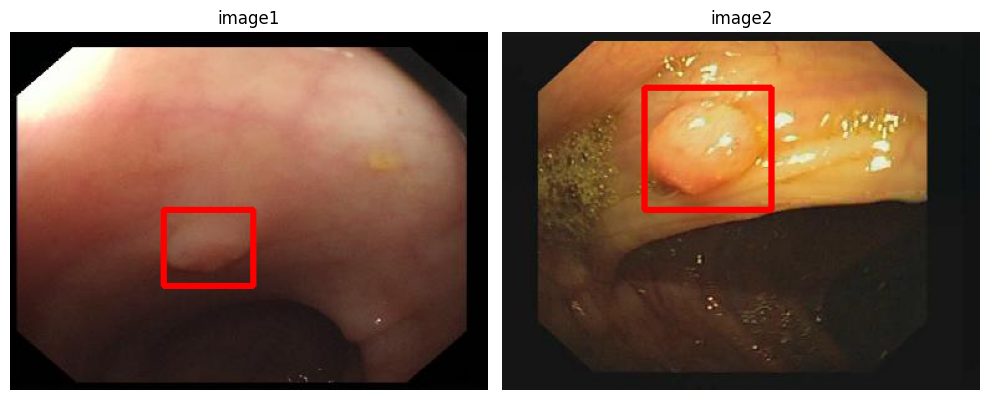

Validation Samples:


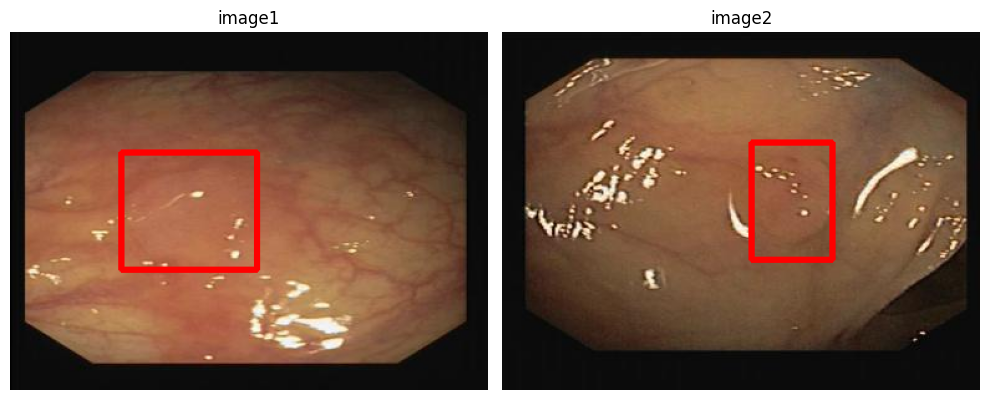

Test Samples:


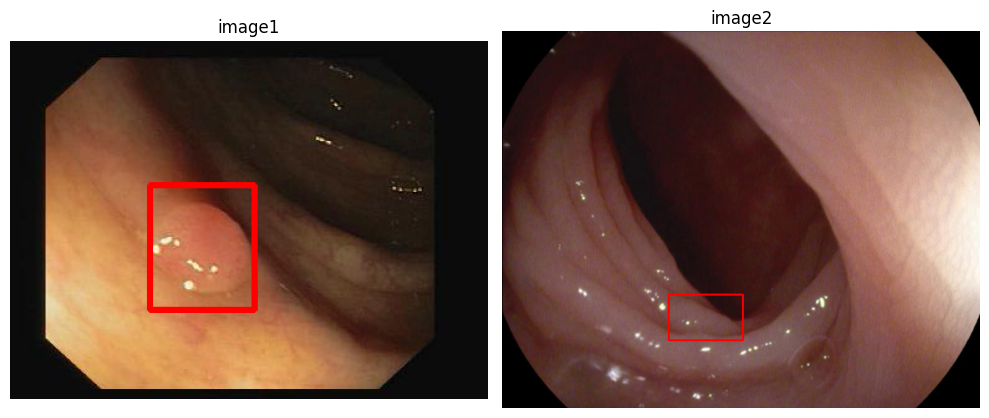

In [14]:
print("Training Samples:")
visualize_samples(config["train"]+"/images", config["train"]+"/labels", 2)
print("Validation Samples:")
visualize_samples(config["val"]+"/images", config["val"]+"/labels", 2)
print("Test Samples:")
visualize_samples(config["test"]+"/images", config["test"]+"/labels", 2)


In [15]:
from PIL import Image

def analyze_split(split_name, img_dir, label_dir):

  stats = {
      "total_images":0,
      "with_polyp":0,
      "background":0,
      "missing_labels":[],
      "widths":[],
      "heights":[]
  }

  if not os.path.exists(img_dir):
    print(f"Directory {img_dir} doesn't exist.")
    return stats

  for img_name in os.listdir(img_dir):
    stats["total_images"] += 1
    img_path = os.path.join(img_dir, img_name)

    #size of image
    with Image.open(img_path) as img:
      w, h = img.size
      stats["widths"].append(w)
      stats["heights"].append(h)

    # label checking
    label_name = img_name.replace(".jpg", ".txt")
    label_path = os.path.join(label_dir, label_name)

    # label is missing
    if not os.path.exists(label_path):
      stats["missing_labels"].append(img_name)

    else:

      # label file exists but class is missing --> empty --> background image
      if os.path.getsize(label_path) == 0:
        stats["background"] += 1

      else:
        stats["with_polyp"] += 1

  return stats

In [16]:
def generate_report(config):
  print("------------DATASET ANALYSIS------------")

  splits = {
      "Train": (config["train"]+"/images", config["train"]+"/labels"),
      "Validation" : (config["val"]+"/images", config["val"]+"/labels"),
      "Test" : (config["test"]+"/images", config["test"]+"/labels")
  }

  all_widths = []
  all_heights = []

  for split_name, (img_dir, label_dir) in splits.items():
    print(f"---------Analysing {split_name} Split ---------")

    stats = analyze_split(split_name, img_dir, label_dir)

    print(f"Total Images: {stats['total_images']}")
    print(f"Images with Polyp: {stats['with_polyp']}")
    print(f"Background Images (Empty Label): {stats['background']}")
    print(f"Missing Labels Count: {len(stats['missing_labels'])}")

    if stats["missing_labels"]:
      print(f"Missing Label Name:{stats['missing_labels'][:5]}")
      print("\n")


    all_widths.extend(stats["widths"])
    all_heights.extend(stats["heights"])


  print("======== GLOBAL RESOLUTION STATS ========")
  if all_widths and all_heights:
      print(f"Minimum Resolution: {min(all_widths)}x{min(all_heights)}")
      print(f"Maximum Resolution: {max(all_widths)}x{max(all_heights)}")
  else:
      print("No images found to calculate stats.")


In [17]:
import time
start = time.time()
generate_report(config)
end = time.time()
print(end - start,"seconds")

------------DATASET ANALYSIS------------
---------Analysing Train Split ---------
Total Images: 4543
Images with Polyp: 4543
Background Images (Empty Label): 0
Missing Labels Count: 0
---------Analysing Validation Split ---------
Total Images: 649
Images with Polyp: 649
Background Images (Empty Label): 0
Missing Labels Count: 0
---------Analysing Test Split ---------
Total Images: 1312
Images with Polyp: 1312
Background Images (Empty Label): 0
Missing Labels Count: 0
======== GLOBAL RESOLUTION STATS ========
Minimum Resolution: 384x288
Maximum Resolution: 1225x966
0.8022794723510742 seconds


In [18]:
class Letterbox:
    """
    Resize image to a strict square (e.g., 640x640) while preserving the original aspect ratio.
    Pads the shorter side with a gray background (value=114).
    Crucially, it recalculates the YOLO labels so the bounding boxes shift to match the gray padding!
    """
    def __init__(self, target=640, color=(114, 114, 114)):
        self.target = target
        self.color  = color

    def __call__(self, image, labels):
        H, W = image.shape[:2]
        t = self.target

        # 1. Figure out scaling factor (how much to shrink/grow keeping aspect ratio)
        r = min(t / H, t / W)
        new_H = int(round(H * r))
        new_W = int(round(W * r))

        # 2. Resize the image
        resized = cv2.resize(image, (new_W, new_H), interpolation=cv2.INTER_LINEAR)

        # 3. Calculate how much gray padding is needed to make it a perfect square
        pad_h = t - new_H
        pad_w = t - new_W
        top = pad_h // 2
        bot = pad_h - top
        left = pad_w // 2
        right = pad_w - left

        # 4. Add the gray borders
        img_lb = cv2.copyMakeBorder(
            resized, top, bot, left, right,
            cv2.BORDER_CONSTANT, value=self.color
        )

        # 5. Shift the bounding box coordinates to account for the new gray borders
        if labels.shape[0] > 0:
            labels = labels.copy().astype(np.float32)

            # Convert YOLO format back to absolute Pixel coordinates
            labels[:, 1] = labels[:, 1] * W          # cx px
            labels[:, 2] = labels[:, 2] * H          # cy px
            labels[:, 3] = labels[:, 3] * W          # w  px
            labels[:, 4] = labels[:, 4] * H          # h  px

            # Scale coordinates down by the same shrink factor as the image
            labels[:, 1:] = labels[:, 1:] * r

            # Shift the coordinates over by the exact size of the gray border padding
            labels[:, 1] += left
            labels[:, 2] += top

            # Re-normalize back to YOLO format (0.0 to 1.0) based on the new 640x640 size
            labels[:, 1] = labels[:, 1] / t          # cx
            labels[:, 2] = labels[:, 2] / t          # cy
            labels[:, 3] = labels[:, 3] / t          # w
            labels[:, 4] = labels[:, 4] / t          # h

            # Safety clip so boxes don't bleed off the edge
            labels[:, 1:] = labels[:, 1:].clip(0.0, 1.0)

        return img_lb, labels


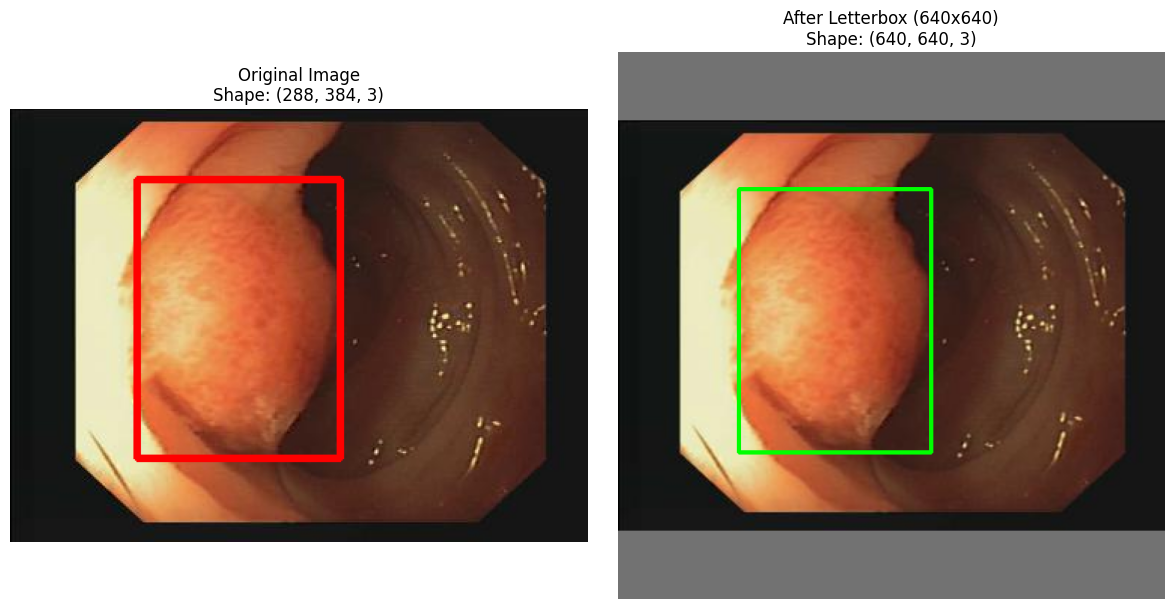

In [19]:
import matplotlib.pyplot as plt

def draw_yolo_boxes(img, labels, color=(255, 0, 0)):
    """Helper function to draw YOLO format labels onto an image."""
    img_draw = img.copy()
    h, w, _ = img_draw.shape

    if len(labels) == 0:
        return img_draw

    for lbl in labels:
        cls_id, cx, cy, bw, bh = lbl
        # Convert normalized YOLO format (0 to 1) back to absolute pixels
        x_center, y_center = int(cx * w), int(cy * h)
        box_width, box_height = int(bw * w), int(bh * h)

        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)
        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 3)
    return img_draw

# 1. Paths to your training data
train_img_dir = "/content/local_dataset/polyp_detection/dataset/train/images"
train_lbl_dir = "/content/local_dataset/polyp_detection/dataset/train/labels"

# 2. Pick a random image
all_images = os.listdir(train_img_dir)
random_img_name = random.choice(all_images)
img_path = os.path.join(train_img_dir, random_img_name)
lbl_path = os.path.join(train_lbl_dir, random_img_name.replace('.jpg', '.txt'))

# 3. Load the Original Image and Labels
orig_img = cv2.imread(img_path)
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

labels = []
if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
    with open(lbl_path, 'r') as f:
        for line in f.readlines():
            labels.append([float(x) for x in line.strip().split()])
labels = np.array(labels, dtype=np.float32)

# ----- APPLY LETTERBOX -----
# Instantiate your class with a target of 640x640
letterbox_transform = Letterbox(target=640)
# Perform the math
lb_img, lb_labels = letterbox_transform(orig_img, labels)
# ---------------------------

# Draw boxes on both
img_with_boxes = draw_yolo_boxes(orig_img, labels, color=(255, 0, 0))       # Red for Original
lb_img_with_boxes = draw_yolo_boxes(lb_img, lb_labels, color=(0, 255, 0))   # Green for Letterbox

# Plot side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_with_boxes)
plt.title(f"Original Image\nShape: {orig_img.shape}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lb_img_with_boxes)
plt.title(f"After Letterbox (640x640)\nShape: {lb_img.shape}")
plt.axis('off')

plt.tight_layout()
plt.show()


In [20]:
def augment_hsv(image, h_gain=0.015, s_gain=0.7, v_gain=0.4):
    """
    Randomly jitter Hue (Color), Saturation (Intensity), and Value (Brightness) of the image in-place.
    This simulates having endoscopes with different lighting / white-balance.
    Does NOT touch the labels since the polyp's location hasn't moved.
    """
    r = np.random.uniform(-1, 1, 3) * [h_gain, s_gain, v_gain] + 1
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Split into channels and apply gain math
    h, s, v = cv2.split(hsv.astype(np.float32))
    h = (h * r[0]) % 180
    s = np.clip(s * r[1], 0, 255)
    v = np.clip(v * r[2], 0, 255)

    hsv_aug = cv2.merge([h, s, v]).astype(np.uint8)
    cv2.cvtColor(hsv_aug, cv2.COLOR_HSV2RGB, dst=image)


def augment_hflip(image, labels):
    """
    Horizontally flip the image (like a mirror).
    Reverses the X-coordinates of the bounding boxes so they track the flipped polyp.
    """
    # Flip image horizontally (Left <-> Right)
    image = image[:, ::-1, :].copy()

    if labels.shape[0] > 0:
        labels = labels.copy()
        # Flip the x-center coordinate (cx goes from e.g., 0.8 to 0.2)
        labels[:, 1] = 1.0 - labels[:, 1]

    return image, labels


def load_label(label_path):
    """
    Helper function to safely read a YOLO .txt file.
    Returns the bounding boxes as a numpy array.
    """
    path = Path(label_path)
    # If there is no file, or it's empty (background image), return an empty array
    if not path.exists() or path.stat().st_size == 0:
        return np.zeros((0, 5), dtype=np.float32)

    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5: # [class, cx, cy, w, h]
                labels.append([float(x) for x in parts])

    if len(labels) == 0:
        return np.zeros((0, 5), dtype=np.float32)

    return np.array(labels, dtype=np.float32)


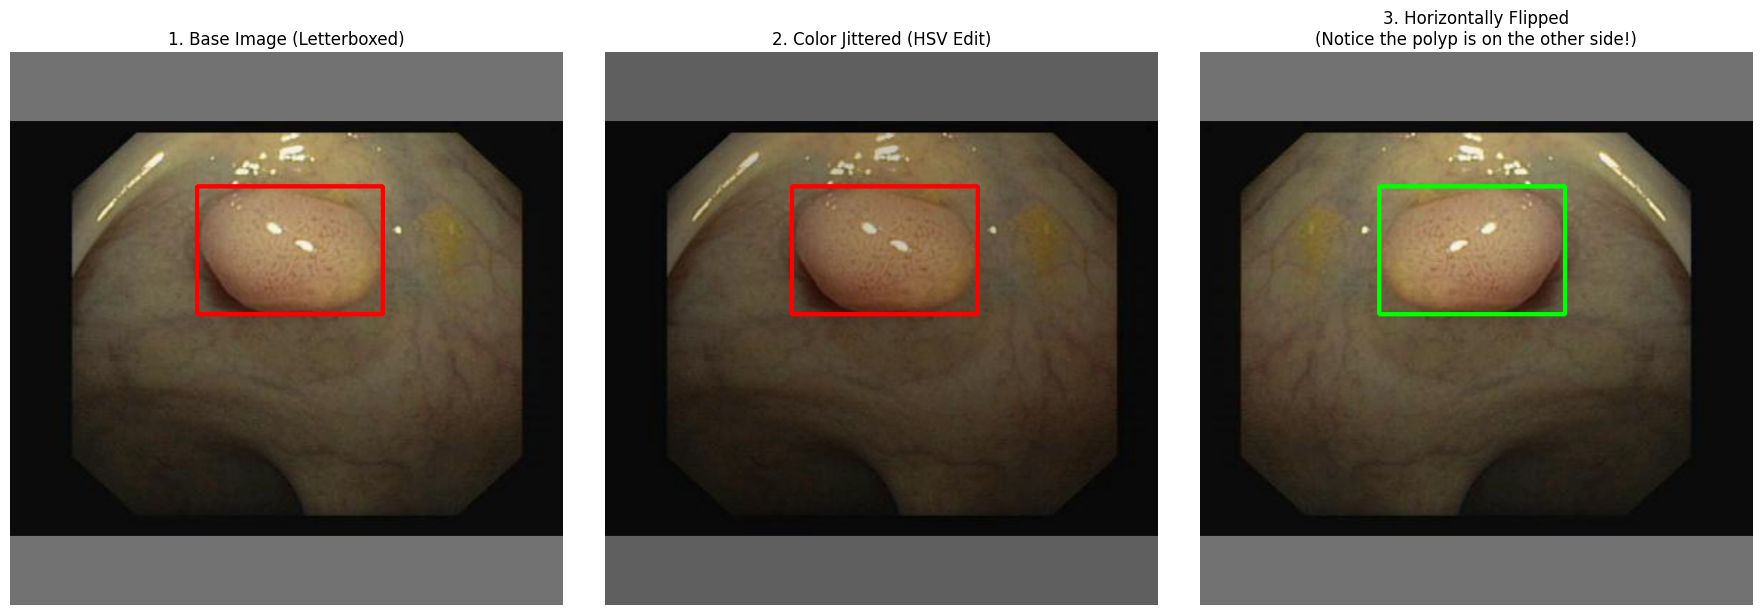

In [21]:
# Assuming 'draw_yolo_boxes', 'train_img_dir', and 'train_lbl_dir'
# are still in memory from the previous verification cell.

# 1. Grab a random image
random_img_name = random.choice(all_images)
img_path = os.path.join(train_img_dir, random_img_name)
lbl_path = os.path.join(train_lbl_dir, random_img_name.replace('.jpg', '.txt'))

orig_img = cv2.imread(img_path)
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Using our new handy label reader!
labels = load_label(lbl_path)

# --- BASELINE: Apply Letterbox first so everything is 640x640 ---
lb = Letterbox(target=640)
base_img, base_labels = lb(orig_img, labels)

# --- TEST 1: Color Jitter (HSV) ---
# We use .copy() because augment_hsv edits the image in-place
hsv_img = base_img.copy()
# (I artificially turned the gain up very high here just so it's visually obvious on your plot)
augment_hsv(hsv_img, h_gain=0.1, s_gain=0.9, v_gain=0.9)
hsv_labels = base_labels.copy() # Bounding boxes don't move when colors change!

# --- TEST 2: Horizontal Flip ---
# This function returns a new image and new labels
flip_img, flip_labels = augment_hflip(base_img.copy(), base_labels.copy())


# --- DRAW BOXES ---
base_viz = draw_yolo_boxes(base_img, base_labels, color=(255, 0, 0)) # Red
hsv_viz = draw_yolo_boxes(hsv_img, hsv_labels, color=(255, 0, 0))    # Red
flip_viz = draw_yolo_boxes(flip_img, flip_labels, color=(0, 255, 0)) # Green

# --- PLOT THE RESULTS ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(base_viz)
plt.title("1. Base Image (Letterboxed)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hsv_viz)
plt.title("2. Color Jittered (HSV Edit)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_viz)
plt.title("3. Horizontally Flipped\n(Notice the polyp is on the other side!)")
plt.axis('off')

plt.tight_layout()
plt.show()


In [22]:
class PolyDataset(Dataset):
    """
    Dataset for polyp detection.
    Reads images and YOLO-format labels from the standard directory layout.
    """
    IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, yaml_path, split='train', img_size=640, augment=False):
        self.img_size = img_size
        self.augment  = augment
        self.letterbox = Letterbox(target=img_size)

        # ── read data.yaml ────────────────────────────────────────────
        with open(yaml_path) as f:
            cfg = yaml.safe_load(f)

        self.nc    = cfg.get('nc', 1)
        self.names = cfg.get('names', ['polyp'])

        # resolve base directory relative to yaml location
        base = Path(yaml_path).parent

        # map split name to yaml key
        split_key = split
        if split_key not in cfg and split == 'valid' and 'val' in cfg:
            split_key = 'val'
        if split_key not in cfg and split == 'val' and 'valid' in cfg:
            split_key = 'valid'

        split_path = Path(cfg[split_key])
        if not split_path.is_absolute():
            split_path = base / split_path

        # ── build image list ──────────────────────────────────────────
        img_dir = split_path / 'images'
        if not img_dir.exists():
            img_dir = split_path

        self.img_paths = sorted([
            p for p in img_dir.iterdir()
            if p.suffix.lower() in self.IMG_EXTENSIONS
        ])

        if len(self.img_paths) == 0:
            raise FileNotFoundError(f"No images found in {img_dir}")

        # ── derive label paths ────────────────────────────────────────
        self.lbl_paths = []
        for img_p in self.img_paths:
            lbl_p = Path(str(img_p).replace(
                os.sep + 'images' + os.sep,
                os.sep + 'labels' + os.sep
            )).with_suffix('.txt')
            self.lbl_paths.append(lbl_p)

        print(f"[PolyDataset] split={split}  images={len(self.img_paths)}  augment={augment}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # load image
        img = cv2.imread(str(self.img_paths[idx]))
        if img is None:
            raise IOError(f"Could not read image: {self.img_paths[idx]}")

        # load labels
        labels = load_label(self.lbl_paths[idx])

        # letterbox
        img, labels = self.letterbox(img, labels)

        # augmentations
        if self.augment:
            augment_hsv(img)
            if random.random() < 0.5:
                img, labels = augment_hflip(img, labels)

        # to tensor
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1).contiguous()

        labels = torch.from_numpy(labels)

        return img, labels

def collate_fn(batch):
    imgs, label_list = zip(*batch)
    imgs = torch.stack(imgs, dim=0)

    max_gt = max(lbl.shape[0] for lbl in label_list)
    max_gt = max(max_gt, 1)

    B = len(label_list)
    padded = torch.zeros(B, max_gt, 5)
    for i, lbl in enumerate(label_list):
        if lbl.shape[0] > 0:
            padded[i, :lbl.shape[0]] = lbl

    return imgs, padded

def build_dataloaders(yaml_path, img_size=640, batch_size=16, num_workers=2):
    train_ds = PolyDataset(yaml_path, split='train', img_size=img_size, augment=True)
    val_ds   = PolyDataset(yaml_path, split='valid', img_size=img_size, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader


In [23]:
yaml_path = '/content/local_dataset/polyp_detection/dataset/data.yaml'

try:
    print("Initializing DataLoaders...")
    # This boots up the Dataset class and multi-processing workers
    train_loader, val_loader = build_dataloaders(yaml_path, img_size=640, batch_size=16)

    print("\nFetching one batch of 16 images from the Train Loader...")
    # This triggers the __getitem__, Letterbox, Augmentations, and collate_fn
    batch_imgs, batch_labels = next(iter(train_loader))

    print("\n✅ SUCCESS! The PyTorch Engine is running.")
    print("-" * 60)
    print("WHAT THE GPU SEES:")
    print("-" * 60)

    print(f"1. Images Tensor Shape : {batch_imgs.shape}")
    print("   -> [Batch_Size=16, Channels=3, Height=640, Width=640]\n")

    print(f"2. Raw Pixel Stats     : Min = {batch_imgs.min():.4f} | Max = {batch_imgs.max():.4f}")
    print("   -> (This should be exactly bounded between 0.0 and 1.0!)\n")

    print(f"3. Labels Tensor Shape : {batch_labels.shape}")
    print("   -> [Batch_Size=16, Max_Polyps_in_this_Batch, 5_YOLO_Parameters]\n")

    print("4. Example Label Data  : [Class_ID, Center_X, Center_Y, Width, Height]")
    # Printing the first bounding box from the first image in the batch
    print(f"   -> Example Box array: {batch_labels[0][0].numpy().round(3)}")

except Exception as e:
    print(f"\n❌ Error building pipeline! Check the traceback: {e}")


Initializing DataLoaders...
[PolyDataset] split=train  images=4543  augment=True
[PolyDataset] split=valid  images=649  augment=False

Fetching one batch of 16 images from the Train Loader...

✅ SUCCESS! The PyTorch Engine is running.
------------------------------------------------------------
WHAT THE GPU SEES:
------------------------------------------------------------
1. Images Tensor Shape : torch.Size([16, 3, 640, 640])
   -> [Batch_Size=16, Channels=3, Height=640, Width=640]

2. Raw Pixel Stats     : Min = 0.0000 | Max = 1.0000
   -> (This should be exactly bounded between 0.0 and 1.0!)

3. Labels Tensor Shape : torch.Size([16, 1, 5])
   -> [Batch_Size=16, Max_Polyps_in_this_Batch, 5_YOLO_Parameters]

4. Example Label Data  : [Class_ID, Center_X, Center_Y, Width, Height]
   -> Example Box array: [0.    0.654 0.353 0.438 0.388]
